In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('/home/admin/Documents/98_model/src')
sys.path.append('/data01/Documents/98_model/src')

# Import modules

In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

import seaborn as sns
import xgboost as xgb
import yaml
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import KFold

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_log_error
import xgboost as xgb
from tqdm import tqdm
import re
import pickle
from sklearn.metrics import roc_curve, auc
import re

from tqdm import trange
import pickle
import os
import optuna

from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
import threading
import gc

from sklearn.manifold import TSNE
import umap
import dill
from matplotlib.patches import FancyArrowPatch
from sklearn.metrics import root_mean_squared_error

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

In [5]:
from utils import PROCESS_STEPS, INPUT_PROFILE, DATA_TYPES
from utils import ColumnClassifier
from utils import squeeze_list

# Environment variables

In [6]:
SHOW_DISTRIBUTION = False
PERFORM_CROSS_VALIDATION = True
PERFORM_BACKTEST = False

In [7]:
FILEPATH_PCA_MODEL_SV = 'PCA_MODEL_SV.dill'
FILEPATH_PCA_MODEL_IQC = 'PCA_MODEL_IQC.dill'
FILEPATH_PCA_MODEL_SV_IQC = 'PCA_MODEL_SV_IQC_.dill'

In [8]:
model_name = 'N32S'
n_trials = 1
lb_margin = 0.05
ub_margin = 0.05
threshold_constraint = 4

model_version = 'v2'

# Load data

In [9]:
try : 
    data_path = '/home/admin/Documents/98_model/notebooks/260714_feature_engineering_qa/feature_store_v10_n32s.parquet'
    data = pd.read_parquet(data_path)
except : 
    data_path = '/data01/Documents/98_model/notebooks/260714_feature_engineering_qa/feature_store_v10_n32s.parquet'
    data = pd.read_parquet(data_path)
data

,07_Before Degas_Cell ID,BASE_ID,01_Mixing_Lot ID,01_Mixing_Equipment ID,01_Mixing_Finished Date,02_Coating(Back)_Lot ID,02_Coating(Back)_Equipment ID,02_Coating(Back)_Finished Date,03_Roll Pressing_Lot ID,03_Roll Pressing_Equipment ID,...,DV86__음극 Buffer 수동 장력 * 가속도 WINDING 1,DV86__음극 Buffer 수동 장력 * 가속도 WINDING 2,DV86__양극 스풀 장력 * 가속도 WINDING 1,DV86__양극 스풀 장력 * 가속도 WINDING 2,DV88_ABW_용접 시간xVoltage,DV88_CSZ_용접 시간xVoltage,DV88_CRW_용접 시간xVoltage,DV88_CBD_용접 시간xVoltage,DV88_CCR_용접 시간xVoltage,DV88_ELF_용접 시간xVoltage
0,07TCED7LGC0021G2B2016718,59JFB112A1,5A2F201001,M2EMIX01602,2026-02-02 01:28:10,5CF1T1A5C1,M2ECOT001,2026-01-30 06:12:56,5CF1T1A5R2,M2EROL015,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,07TCED7LGC0021G2E2063322,59JFB142A1,5A2F201001,M2EMIX01602,2026-02-02 01:28:10,5AF2A131C1,M2ECOT002,2026-02-10 14:14:12,5AF2A131R1,M2EROL014,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07TCED7LGC0021G2G2018702,59JFB162A1,5A3F209041,M2EMIX01702,2026-02-09 19:11:46,5CF1V165C1,M2ECOT001,2026-01-31 18:56:59,5CF1V165R1,M2EROL015,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,07TCED7LGC0021G382040158,59JFC082A1,5C1F225029,M2EMIX01103,2026-02-26 00:00:57,5CF2R151C1,M2ECOT001,2026-02-27 17:44:29,5CF2R151R1,M2EROL015,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,07TCED7LGC0021G3S2044730,59JFC252A1,5C2F309007,M2EMIX01203,2026-03-09 21:02:14,5CF3E183C1,M2ECOT001,2026-03-14 20:58:31,5CF3E183R1,M2EROL015,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14824,None,59JFC302A1,5A4F320066,M2EMIX01802,2026-03-20 15:59:56,5AF3K177C1,M2ECOT002,2026-03-20 23:44:37,5AF3K177R1,M2EROL014,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14825,None,59JFC302A1,5C1F324051,M2EMIX01103,2026-03-24 15:31:54,5CF3P182C1,M2ECOT001,2026-03-25 22:57:45,5CF3P182R1,M2EROL012,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14826,None,59JFC302A1,5C2F324047,M2EMIX01203,2026-03-24 12:58:56,5CF3P135C1,M2ECOT001,2026-03-25 14:02:37,5CF3P135R1,M2EROL015,...,162.5,NaN,234.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14827,None,59JFC302A1,5C2F324047,M2EMIX01203,2026-03-24 12:58:56,5CF3P164C1,M2ECOT001,2026-03-25 19:24:35,5CF3P164R1,M2EROL012,...,250.0,NaN,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
data_path_weekly_defect = '/home/admin/Documents/98_model/data/weekly_defect_n32s.parquet'
data_path_weekly_defect_vm2 = '/data01/Documents/98_model/data/weekly_defect_n32s.parquet'

try : 
    weekly_score = pd.read_parquet(data_path_weekly_defect)
except : 
    weekly_score = pd.read_parquet(data_path_weekly_defect_vm2)

# Get column names

In [11]:
column_classifier = ColumnClassifier()
df_cols = column_classifier.transform(data=data)

In [12]:
cols_small_y = (
    df_cols.loc[lambda x :x['data_type'] == 'Small_Y', 'cols']
    .tolist()
)
cols_small_y = squeeze_list(cols_small_y)
cols_small_y = [x for x in cols_small_y if x in data.columns]
cols_small_y[:5]

['y_MES_Electrode_Coating_Cathode_치수_Loading (Back)',
 'y_LQC_Electrode_Coating_Cathode_Sliding (-)_Tab Back',
 'y_MES_Electrode_Coating_Cathode_외관_접힘 (Top)',
 'y_MES_Electrode_Coating_Anode_치수_Mismatch (Back)',
 'y_MES_Electrode_Coating_Anode_치수_Loading (Top)']

In [13]:
cols_sv = (
    df_cols.loc[lambda x :x['data_type'] == 'SV', 'cols']
    .tolist()
)
cols_sv = squeeze_list(cols_sv)
cols_sv[:5]

['X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time',
 'X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6',
 'X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6',
 'X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight']

In [14]:
cols_major_sv = [
    
]
# TODO : 주요 SV 받아서 변경 필요

cols_minor_sv = [

]

In [15]:
cols_big_y = [
    'Y_NFF_A',
    'Y_NFF_E',
    'Y_NFF_J',
    'Y_NFF_F',
    'Y_NFF_R',
    'Y_NFF_V'
]

In [16]:
cols_iqc = [x for x in data.columns if 'IQC' in x]
cols_iqc[:5]

['X_IQC_Assemble_Assembly_두께_1',
 'X_IQC_Assemble_Assembly_돌기부_외경',
 'X_IQC_Assemble_Assembly_중심부Hole_동심도',
 'X_IQC_Assemble_Assembly_외경',
 'X_IQC_Assemble_Assembly_두께_4']

# Preprocess data

In [17]:
# 0. Big Y 없는 row 제거
data = data[data['Y_NFF_A'].notnull()]

In [18]:
# 1. 중복 컬럼 제거
data = data.loc[:, ~data.columns.duplicated()]

In [19]:
# 2. datetime 처리
col_target_date = '06_Assembly_Finished Date'
data[col_target_date] = pd.to_datetime(data[col_target_date])
data['week'] = data[col_target_date].dt.isocalendar().week
data['date'] = data[col_target_date].dt.date

In [20]:
# 3. Category로 되어있는 Small y 인코딩
def encode_small_y(x) :
    # NG -> 불량 -> 1
    # OK -> 정상 -> 0
    if x == 'NG' :
        y = 1
    elif x == 'OK' : 
        y = 0 
    else : 
        y = x
    return y

for col in tqdm(cols_small_y) : 
    data[col] = data[col].apply(lambda x: encode_small_y(x))
    

100%|██████████| 134/134 [00:01<00:00, 75.74it/s]


In [21]:
# 4. 모든 Row가 결측치인 Small y drop

drop_cols = data[cols_small_y].columns[data[cols_small_y].isna().all()]
data = data.drop(columns=drop_cols)

cols_small_y_nan_dropped = [x for x in cols_small_y if x in data.columns]

# cols_small_y weekly score에 있는것만 발라내기
cols_small_y_nan_dropped = [x for x in cols_small_y_nan_dropped if x in weekly_score.columns]

data[cols_small_y_nan_dropped].isna().sum()

y_MES_Electrode_Coating_Cathode_치수_Loading (Back)    2042
y_MES_Electrode_Coating_Cathode_외관_접힘 (Top)          2042
y_MES_Electrode_Coating_Anode_치수_Mismatch (Back)     1618
y_MES_Electrode_Coating_Anode_치수_Loading (Top)       1618
y_MES_Electrode_Coating_Cathode_외관_표면 (Top)          2042
                                                     ... 
y_MES_Electrode_Slitting_Anode_절연_LINE               1622
y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면        1622
y_MES_Electrode_Slitting_Anode_외관-손상-탈리-단선           1622
y_MES_Electrode_Slitting_Cathode_절연_LINE             1368
y_MES_Electrode_Slitting_Cathode_유지부_SLT면_탈리         1368
Length: 114, dtype: int64

In [22]:
# 5. Small y 결측치 Historical cumalative mean으로 fill
data[cols_small_y_nan_dropped].describe()

,y_MES_Electrode_Coating_Cathode_치수_Loading (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_치수_Loading (Top),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_LQC_Electrode_Coating_Cathode_Sliding(+)_Tab Top,y_MES_Electrode_Coating_Cathode_외관_단선 (Top),y_MES_Electrode_Coating_Cathode_외관_단선 (Back),...,y_MES_Electrode_Slitting_Anode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-손상-찍힘/눌림-찍힘,y_MES_Electrode_Slitting_Cathode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-변형-아일랜드-표면,y_MES_Electrode_Slitting_Anode_유지부_SLT면_탈리,y_MES_Electrode_Slitting_Anode_절연_LINE,y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면,y_MES_Electrode_Slitting_Anode_외관-손상-탈리-단선,y_MES_Electrode_Slitting_Cathode_절연_LINE,y_MES_Electrode_Slitting_Cathode_유지부_SLT면_탈리
count,57018.000000,57018.0,57442.0,57442.0,57018.000000,57442.000000,57018.0,8262.000000,57018.0,57018.0,...,57438.000000,57692.000000,57692.000000,57692.000000,57438.0,57438.0,57438.000000,57438.000000,57692.000000,57692.000000
mean,0.054720,0.0,0.0,0.0,2.407410,0.615577,0.0,0.926731,0.0,0.0,...,0.008299,0.028250,0.459636,0.140782,0.0,0.0,0.039338,0.198492,0.061126,0.019816
std,1.280086,0.0,0.0,0.0,17.795562,9.103676,0.0,0.247233,0.0,0.0,...,0.216788,1.530265,3.282656,0.928714,0.0,0.0,0.439979,3.276342,3.759355,1.077180
min,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.183333,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.783333,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.933333,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,1.100000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
max,30.000000,0.0,0.0,0.0,214.300000,300.000000,0.0,1.566667,0.0,0.0,...,6.300000,135.000000,326.000000,18.200000,0.0,0.0,35.000000,135.000000,299.700000,90.100000


In [23]:
hist_mean = data[cols_small_y_nan_dropped].expanding().mean().shift(1)
data[cols_small_y_nan_dropped] = data[cols_small_y_nan_dropped].fillna(hist_mean)

In [24]:
data[cols_small_y_nan_dropped]

,y_MES_Electrode_Coating_Cathode_치수_Loading (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_치수_Loading (Top),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_LQC_Electrode_Coating_Cathode_Sliding(+)_Tab Top,y_MES_Electrode_Coating_Cathode_외관_단선 (Top),y_MES_Electrode_Coating_Cathode_외관_단선 (Back),...,y_MES_Electrode_Slitting_Anode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-손상-찍힘/눌림-찍힘,y_MES_Electrode_Slitting_Cathode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-변형-아일랜드-표면,y_MES_Electrode_Slitting_Anode_유지부_SLT면_탈리,y_MES_Electrode_Slitting_Anode_절연_LINE,y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면,y_MES_Electrode_Slitting_Anode_외관-손상-탈리-단선,y_MES_Electrode_Slitting_Cathode_절연_LINE,y_MES_Electrode_Slitting_Cathode_유지부_SLT면_탈리
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# 6. Historical mean으로 안채워지는거 0으로 fill
data[cols_small_y_nan_dropped] = data[cols_small_y_nan_dropped].fillna(0)

In [26]:
data[cols_small_y_nan_dropped]

,y_MES_Electrode_Coating_Cathode_치수_Loading (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_치수_Loading (Top),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_LQC_Electrode_Coating_Cathode_Sliding(+)_Tab Top,y_MES_Electrode_Coating_Cathode_외관_단선 (Top),y_MES_Electrode_Coating_Cathode_외관_단선 (Back),...,y_MES_Electrode_Slitting_Anode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-손상-찍힘/눌림-찍힘,y_MES_Electrode_Slitting_Cathode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-변형-아일랜드-표면,y_MES_Electrode_Slitting_Anode_유지부_SLT면_탈리,y_MES_Electrode_Slitting_Anode_절연_LINE,y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면,y_MES_Electrode_Slitting_Anode_외관-손상-탈리-단선,y_MES_Electrode_Slitting_Cathode_절연_LINE,y_MES_Electrode_Slitting_Cathode_유지부_SLT면_탈리
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14569,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.926700,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# 7. IQC 결측치 Historical cumalative mean으로 fill
cols_target = cols_iqc

data[cols_target].describe()

hist_mean = data[cols_target].expanding().mean().shift(1)
data[cols_target] = data[cols_target].fillna(hist_mean)

# Historical mean으로 안채워지는거 0으로 fill
data[cols_target] = data[cols_target].fillna(0)

data[cols_target]

,X_IQC_Assemble_Assembly_두께_1,X_IQC_Assemble_Assembly_돌기부_외경,X_IQC_Assemble_Assembly_중심부Hole_동심도,X_IQC_Assemble_Assembly_외경,X_IQC_Assemble_Assembly_두께_4,X_IQC_Assemble_Assembly_두께_2,X_IQC_Assemble_Assembly_중심부Hole_외경,X_IQC_Assemble_Assembly_두께_3,X_IQC_Assemble_Assembly_외관,X_IQC_Assemble_Assembly_Side_Hole_직경_2,...,X_IQC_Electrode_Coating_Anode_인장강도,X_IQC_Electrode_Coating_Cathode_인장강도,X_IQC_Electrode_Coating_Anode_Dyne_Test,X_IQC_Electrode_Coating_Cathode_Dyne_Test,X_IQC_Electrode_Coating_Anode_연신율,X_IQC_Electrode_Coating_Cathode_연신율,X_IQC_Electrode_Coating_Anode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Anode_표면조도_Air_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Air_Ra
0,0.618141,45.318000,0.028750,41.428580,0.690934,0.246727,13.499750,0.281614,0.0,2.977556,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
1,0.593969,45.318000,0.028750,41.416891,0.705874,0.243909,13.499750,0.276783,0.0,2.977556,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
2,0.626175,45.320250,0.024250,41.735460,0.780391,0.247585,13.502750,0.275914,0.0,2.973000,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
3,0.601268,45.318800,0.026800,41.600597,0.760074,0.245199,13.500000,0.277656,0.0,2.972218,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
4,0.460907,45.279333,0.024667,40.386835,0.504042,0.227508,13.514667,0.247813,0.0,2.967895,...,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,0.610358,45.296429,0.028214,41.757182,0.820768,0.244664,13.500153,0.277876,0.0,2.968359,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0
14568,0.633112,45.320250,0.024250,41.734844,0.771714,0.248399,13.502750,0.277188,0.0,2.973000,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0
14569,0.736999,45.278095,0.024286,42.355159,0.891392,0.256109,13.512381,0.289099,0.0,2.967000,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0
14570,0.479582,45.297333,0.032333,40.807354,0.597582,0.231191,13.498333,0.258297,0.0,2.980000,...,33.38,0.0,0.0,0.0,16.87,0.0,0.24,0.0,0.235,0.0


In [28]:
# 8. SV 결측치 Historical cumalative mean으로 fill
cols_target = cols_sv

data[cols_target].describe()

hist_mean = data[cols_target].expanding().mean().shift(1)
data[cols_target] = data[cols_target].fillna(hist_mean)

# Historical mean으로 안채워지는거 0으로 fill
data[cols_target] = data[cols_target].fillna(0)

data[cols_target]

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
0,40.0,0.0,0.0,0.0,475.5,0.000000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
1,40.0,0.0,0.0,0.0,475.5,0.000000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
2,40.0,0.0,0.0,0.0,472.1,0.000000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
3,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
4,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14567,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
14568,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
14569,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
14570,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


# Show distribution

## Weekly score

In [29]:
if model_name == 'N32S' :
    # TODO : [x] 연주님 준 파일로 변경
    # weekly_score = (
    #     data
    #     .groupby('week')
    #     [cols_big_y + cols_small_y_nan_dropped].mean()
    # )
    

    weekly_score = (
        weekly_score
        .drop('date', axis=1)
        .set_index('week')
        .loc[:, cols_big_y+[x for x in cols_small_y_nan_dropped if x in weekly_score.columns]]
    )
elif model_name == 'N33Q' : 
    weekly_score = (
        data
        .groupby('week')
        [cols_big_y + cols_small_y_nan_dropped].mean()
    )
weekly_score

,Y_NFF_A,Y_NFF_E,Y_NFF_J,Y_NFF_F,Y_NFF_R,Y_NFF_V,y_MES_Electrode_Coating_Cathode_치수_Loading (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_치수_Loading (Top),...,y_MES_Electrode_Slitting_Anode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-손상-찍힘/눌림-찍힘,y_MES_Electrode_Slitting_Cathode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-변형-아일랜드-표면,y_MES_Electrode_Slitting_Anode_유지부_SLT면_탈리,y_MES_Electrode_Slitting_Anode_절연_LINE,y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면,y_MES_Electrode_Slitting_Anode_외관-손상-탈리-단선,y_MES_Electrode_Slitting_Cathode_절연_LINE,y_MES_Electrode_Slitting_Cathode_유지부_SLT면_탈리
week,,,,,,,,,,,,,,,,,,,,,
5,0.779928,0.036188,0.000000,0.000000,0.001262,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.447780,0.273150,0.0,0.0,0.000000,0.000000,0.009292,0.057800
6,0.756719,0.045854,0.058026,0.000000,0.004869,0.000397,0.326465,0.0,0.0,0.0,...,0.000000,0.000000,0.471079,0.325792,0.0,0.0,0.033885,0.186853,0.282822,0.000000
7,0.843122,0.043469,0.000000,0.000000,0.003526,0.000737,0.028669,0.0,0.0,0.0,...,0.000000,0.023347,0.786112,0.217357,0.0,0.0,0.069045,0.004122,0.006116,0.098197
8,0.902518,0.052766,0.000000,0.000000,0.001238,0.000757,0.000000,0.0,0.0,0.0,...,0.000000,0.132706,0.511073,0.108945,0.0,0.0,0.017543,0.284008,0.011122,0.012835
9,0.754826,0.038231,0.000000,0.000000,0.008369,0.000190,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.647732,0.035189,0.0,0.0,0.018149,0.548136,0.000000,0.000000
10,0.918926,0.039026,0.002014,0.000000,0.001511,0.004448,0.000000,0.0,0.0,0.0,...,0.000000,0.012305,0.512393,0.039244,0.0,0.0,0.069748,0.021168,0.081331,0.007547
11,0.906310,0.036845,0.000000,0.000000,0.002423,0.001070,0.000000,0.0,0.0,0.0,...,0.000000,0.004076,0.110252,0.080769,0.0,0.0,0.082045,0.443974,0.016519,0.000000
12,0.906187,0.029454,0.001052,0.003204,0.001434,0.000813,0.000000,0.0,0.0,0.0,...,0.046604,0.002932,0.327599,0.085949,0.0,0.0,0.021768,0.184948,0.006515,0.000000
13,0.871100,0.034092,0.016757,0.002134,0.004223,0.000933,0.000000,0.0,0.0,0.0,...,0.000000,0.041713,0.375396,0.103977,0.0,0.0,0.001369,0.072971,0.006056,0.000000


In [30]:
historical_small_y_target = (
    weekly_score
    [[x for x in cols_small_y_nan_dropped if x in weekly_score.columns]]
    .expanding().mean()
)
historical_small_y_target

,y_MES_Electrode_Coating_Cathode_치수_Loading (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Top),y_MES_Electrode_Coating_Anode_치수_Mismatch (Back),y_MES_Electrode_Coating_Anode_치수_Loading (Top),y_MES_Electrode_Coating_Cathode_외관_표면 (Top),y_MES_Electrode_Coating_Anode_외관_표면 (Back),y_MES_Electrode_Coating_Cathode_외관_접힘 (Back),y_LQC_Electrode_Coating_Cathode_Sliding(+)_Tab Top,y_MES_Electrode_Coating_Cathode_외관_단선 (Top),y_MES_Electrode_Coating_Cathode_외관_단선 (Back),...,y_MES_Electrode_Slitting_Anode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-손상-찍힘/눌림-찍힘,y_MES_Electrode_Slitting_Cathode_절연 폭,y_MES_Electrode_Slitting_Cathode_외관-변형-아일랜드-표면,y_MES_Electrode_Slitting_Anode_유지부_SLT면_탈리,y_MES_Electrode_Slitting_Anode_절연_LINE,y_MES_Electrode_Slitting_Anode_외관-변형-전극 라인-표면,y_MES_Electrode_Slitting_Anode_외관-손상-탈리-단선,y_MES_Electrode_Slitting_Cathode_절연_LINE,y_MES_Electrode_Slitting_Cathode_유지부_SLT면_탈리
week,,,,,,,,,,,,,,,,,,,,,
5,0.000000,0.0,0.0,0.0,2.445287,0.252578,0.0,0.954622,0.0,0.0,...,0.000000,0.000000,0.447780,0.273150,0.0,0.0,0.000000,0.000000,0.009292,0.057800
6,0.163232,0.0,0.0,0.0,1.243728,0.148886,0.0,0.936328,0.0,0.0,...,0.000000,0.000000,0.459429,0.299471,0.0,0.0,0.016943,0.093426,0.146057,0.028900
7,0.118378,0.0,0.0,0.0,2.077748,0.169559,0.0,0.919450,0.0,0.0,...,0.000000,0.007782,0.568324,0.272100,0.0,0.0,0.034310,0.063658,0.099410,0.051999
8,0.088783,0.0,0.0,0.0,2.805082,0.168438,0.0,0.926353,0.0,0.0,...,0.000000,0.039013,0.554011,0.231311,0.0,0.0,0.030118,0.118746,0.077338,0.042208
9,0.071027,0.0,0.0,0.0,3.423970,0.553934,0.0,0.937678,0.0,0.0,...,0.000000,0.031211,0.572755,0.192087,0.0,0.0,0.027724,0.204624,0.061870,0.033766
10,0.059189,0.0,0.0,0.0,3.543862,0.961122,0.0,0.911238,0.0,0.0,...,0.000000,0.028060,0.562695,0.166613,0.0,0.0,0.034728,0.174048,0.065114,0.029397
11,0.050733,0.0,0.0,0.0,3.261694,0.845370,0.0,0.924907,0.0,0.0,...,0.000000,0.024633,0.498060,0.154350,0.0,0.0,0.041488,0.212609,0.058172,0.025197
12,0.044392,0.0,0.0,0.0,2.875649,0.792906,0.0,0.926693,0.0,0.0,...,0.005825,0.021921,0.476752,0.145800,0.0,0.0,0.039023,0.209151,0.051715,0.022047
13,0.039459,0.0,0.0,0.0,2.778773,0.704805,0.0,0.937954,0.0,0.0,...,0.005178,0.024120,0.465491,0.141153,0.0,0.0,0.034839,0.194020,0.046642,0.019598


## SV distribution

In [31]:
data_sv_last_by_week = (
    data
    .groupby('week')
    [cols_sv].last()
    .fillna(0)
)
data_sv_last_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


In [32]:
model_path = FILEPATH_PCA_MODEL_SV
data_pca = data_sv_last_by_week

In [33]:
if SHOW_DISTRIBUTION :
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_pca)


    if not os.path.exists(model_path) : 
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        with open(model_path, 'wb') as f : 
            dill.dump(pca, f)
    else : 
        with open(model_path, 'rb') as f : 
            pca = dill.load(f)
        X_pca = pca.transform((X_scaled))


In [34]:
if SHOW_DISTRIBUTION :
    print('SHOW DISTRIBUTION')
    data_pca_2dim = pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2'],
        index=getattr(data_pca, "index", None)
    )
    data_pca_2dim[cols_big_y + cols_small_y_nan_dropped] = weekly_score[cols_big_y + cols_small_y_nan_dropped]

    idx_col_y = 0
    col_y = (cols_big_y + cols_small_y_nan_dropped)[idx_col_y]

    x = data_pca_2dim['PC1'].values
    y = data_pca_2dim['PC2'].values
    score = (1-data_pca_2dim[col_y].values)
    week = data_pca_2dim.index.tolist()

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(score.min(), score.max())

    lc = LineCollection(
        segments,
        cmap='viridis',
        norm=norm,
        linewidth=2
    )
    lc.set_array(score[:-1])

    fig, ax = plt.subplots(figsize=(7,6))
    ax.add_collection(lc)

    # Scatter
    sc = ax.scatter(
        x, y,
        c=score,
        cmap='viridis',
        norm=norm,
        s=30,
        edgecolor='k',
        zorder=3
    )

    # #1. 화살표 추가
    for i in range(len(x) - 1) : 
        arrow = FancyArrowPatch(
            (x[i], y[i]),
            (x[i+1], y[i+1]),
            arrowstyle="-|>",
            mutation_scale=10,
            color=plt.cm.viridis(norm(score[i])),
            linewidth=1.5,
            alpha=0.8,
            zorder=2,
        )
        ax.add_patch(arrow)

    # 2. 레이블 추가
    for real_idx, idx in enumerate(data_pca_2dim.index.tolist()) : 
        ax.text(
            x[real_idx],
            y[real_idx],
            f"Week : {week[real_idx]}, Score : {score[real_idx]}",
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc='white',
                alpha=0.7,
                ec='gray'
            )
        )

    ax.autoscale()

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'Defect rate {col_y}')

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Trajectory by week, by {col_y}")

    plt.tight_layout()
    plt.show()

## IQC distribution

In [35]:
data_iqc_mean_by_week = (
    data
    .groupby('week')
    [cols_iqc].mean()
    .fillna(0)
)
data_iqc_mean_by_week

,X_IQC_Assemble_Assembly_두께_1,X_IQC_Assemble_Assembly_돌기부_외경,X_IQC_Assemble_Assembly_중심부Hole_동심도,X_IQC_Assemble_Assembly_외경,X_IQC_Assemble_Assembly_두께_4,X_IQC_Assemble_Assembly_두께_2,X_IQC_Assemble_Assembly_중심부Hole_외경,X_IQC_Assemble_Assembly_두께_3,X_IQC_Assemble_Assembly_외관,X_IQC_Assemble_Assembly_Side_Hole_직경_2,...,X_IQC_Electrode_Coating_Anode_인장강도,X_IQC_Electrode_Coating_Cathode_인장강도,X_IQC_Electrode_Coating_Anode_Dyne_Test,X_IQC_Electrode_Coating_Cathode_Dyne_Test,X_IQC_Electrode_Coating_Anode_연신율,X_IQC_Electrode_Coating_Cathode_연신율,X_IQC_Electrode_Coating_Anode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Anode_표면조도_Air_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Air_Ra
week,,,,,,,,,,,,,,,,,,,,,
5,0.603118,45.305966,0.027226,41.468895,0.711503,0.244478,13.502788,0.275370,0.0,2.973152,...,33.267685,0.0,0.0,0.0,16.813237,0.0,0.239192,0.0,0.234209,0.0
6,0.458838,45.304378,0.031918,40.716561,0.579058,0.228907,13.498476,0.253681,0.0,2.979645,...,33.304326,0.0,0.0,0.0,16.831755,0.0,0.239456,0.0,0.234467,0.0
7,0.652456,45.317367,0.028748,41.761642,0.772815,0.250493,13.499784,0.288184,0.0,2.977350,...,33.339818,0.0,0.0,0.0,16.849692,0.0,0.239711,0.0,0.234717,0.0
8,0.706337,45.320175,0.024400,42.051610,0.803828,0.256748,13.502650,0.290690,0.0,2.972930,...,33.305372,0.0,0.0,0.0,16.832284,0.0,0.239463,0.0,0.234475,0.0
9,0.821686,45.318936,0.024666,42.493600,0.827446,0.270052,13.500937,0.313443,0.0,2.971771,...,33.315962,0.0,0.0,0.0,16.837635,0.0,0.239540,0.0,0.234549,0.0
10,0.605145,45.318151,0.026016,41.475209,0.709572,0.245559,13.499460,0.276872,0.0,2.972121,...,33.348610,0.0,0.0,0.0,16.854136,0.0,0.239774,0.0,0.234779,0.0
11,0.610733,45.310406,0.028149,41.665341,0.776429,0.245587,13.499251,0.279633,0.0,2.972742,...,33.298796,0.0,0.0,0.0,16.828960,0.0,0.239416,0.0,0.234428,0.0
12,0.646215,45.286606,0.026075,41.835321,0.804555,0.247758,13.505933,0.279220,0.0,2.968139,...,33.327139,0.0,0.0,0.0,16.843284,0.0,0.239620,0.0,0.234628,0.0
13,0.507095,45.279711,0.024694,40.709774,0.562547,0.232208,13.513583,0.253528,0.0,2.967280,...,33.316191,0.0,0.0,0.0,16.837751,0.0,0.239541,0.0,0.234551,0.0


In [36]:
model_path = FILEPATH_PCA_MODEL_IQC
data_pca = data_iqc_mean_by_week

In [37]:
if SHOW_DISTRIBUTION :
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_pca)


    if not os.path.exists(model_path) : 
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        with open(model_path, 'wb') as f : 
            dill.dump(pca, f)
    else : 
        with open(model_path, 'rb') as f : 
            pca = dill.load(f)
        X_pca = pca.transform((X_scaled))


In [38]:
if SHOW_DISTRIBUTION :
    print('SHOW DISTRIBUTION')
    data_pca_2dim = pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2'],
        index=getattr(data_pca, "index", None)
    )
    data_pca_2dim[cols_big_y + cols_small_y_nan_dropped] = weekly_score[cols_big_y + cols_small_y_nan_dropped]

    idx_col_y = 0
    col_y = (cols_big_y + cols_small_y_nan_dropped)[idx_col_y]

    x = data_pca_2dim['PC1'].values
    y = data_pca_2dim['PC2'].values
    score = (1-data_pca_2dim[col_y].values)
    week = data_pca_2dim.index.tolist()

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(score.min(), score.max())

    lc = LineCollection(
        segments,
        cmap='viridis',
        norm=norm,
        linewidth=2
    )
    lc.set_array(score[:-1])

    fig, ax = plt.subplots(figsize=(7,6))
    ax.add_collection(lc)

    # Scatter
    sc = ax.scatter(
        x, y,
        c=score,
        cmap='viridis',
        norm=norm,
        s=30,
        edgecolor='k',
        zorder=3
    )

    # #1. 화살표 추가
    for i in range(len(x) - 1) : 
        arrow = FancyArrowPatch(
            (x[i], y[i]),
            (x[i+1], y[i+1]),
            arrowstyle="-|>",
            mutation_scale=10,
            color=plt.cm.viridis(norm(score[i])),
            linewidth=1.5,
            alpha=0.8,
            zorder=2,
        )
        ax.add_patch(arrow)

    # 2. 레이블 추가
    for real_idx, idx in enumerate(data_pca_2dim.index.tolist()) : 
        ax.text(
            x[real_idx],
            y[real_idx],
            f"Week : {week[real_idx]}, Score : {score[real_idx]}",
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc='white',
                alpha=0.7,
                ec='gray'
            )
        )

    ax.autoscale()

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'Defect rate {col_y}')

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Trajectory by week, by {col_y}")

    plt.tight_layout()
    plt.show()

## SV + IQC distribution

In [39]:
data_sv_last_iqc_mean_by_week = pd.concat([
    data_sv_last_by_week,
    data_iqc_mean_by_week
], axis=1)
data_sv_last_iqc_mean_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_IQC_Electrode_Coating_Anode_인장강도,X_IQC_Electrode_Coating_Cathode_인장강도,X_IQC_Electrode_Coating_Anode_Dyne_Test,X_IQC_Electrode_Coating_Cathode_Dyne_Test,X_IQC_Electrode_Coating_Anode_연신율,X_IQC_Electrode_Coating_Cathode_연신율,X_IQC_Electrode_Coating_Anode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Drum_Ra,X_IQC_Electrode_Coating_Anode_표면조도_Air_Ra,X_IQC_Electrode_Coating_Cathode_표면조도_Air_Ra
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,33.267685,0.0,0.0,0.0,16.813237,0.0,0.239192,0.0,0.234209,0.0
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,33.304326,0.0,0.0,0.0,16.831755,0.0,0.239456,0.0,0.234467,0.0
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,33.339818,0.0,0.0,0.0,16.849692,0.0,0.239711,0.0,0.234717,0.0
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,33.305372,0.0,0.0,0.0,16.832284,0.0,0.239463,0.0,0.234475,0.0
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,33.315962,0.0,0.0,0.0,16.837635,0.0,0.239540,0.0,0.234549,0.0
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,33.348610,0.0,0.0,0.0,16.854136,0.0,0.239774,0.0,0.234779,0.0
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,33.298796,0.0,0.0,0.0,16.828960,0.0,0.239416,0.0,0.234428,0.0
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,33.327139,0.0,0.0,0.0,16.843284,0.0,0.239620,0.0,0.234628,0.0
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,33.316191,0.0,0.0,0.0,16.837751,0.0,0.239541,0.0,0.234551,0.0


In [40]:
model_path = FILEPATH_PCA_MODEL_SV_IQC
data_pca = data_sv_last_iqc_mean_by_week

In [41]:
if SHOW_DISTRIBUTION :
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(data_pca)


    if not os.path.exists(model_path) : 
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        with open(model_path, 'wb') as f : 
            dill.dump(pca, f)
    else : 
        with open(model_path, 'rb') as f : 
            pca = dill.load(f)
        X_pca = pca.transform((X_scaled))


In [42]:
if SHOW_DISTRIBUTION :
    print('SHOW DISTRIBUTION')
    data_pca_2dim = pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2'],
        index=getattr(data_pca, "index", None)
    )
    data_pca_2dim[cols_big_y + cols_small_y_nan_dropped] = weekly_score[cols_big_y + cols_small_y_nan_dropped]

    idx_col_y = 0
    col_y = (cols_big_y + cols_small_y_nan_dropped)[idx_col_y]

    x = data_pca_2dim['PC1'].values
    y = data_pca_2dim['PC2'].values
    score = (1-data_pca_2dim[col_y].values)
    week = data_pca_2dim.index.tolist()

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    norm = Normalize(score.min(), score.max())

    lc = LineCollection(
        segments,
        cmap='viridis',
        norm=norm,
        linewidth=2
    )
    lc.set_array(score[:-1])

    fig, ax = plt.subplots(figsize=(7,6))
    ax.add_collection(lc)

    # Scatter
    sc = ax.scatter(
        x, y,
        c=score,
        cmap='viridis',
        norm=norm,
        s=30,
        edgecolor='k',
        zorder=3
    )

    # #1. 화살표 추가
    for i in range(len(x) - 1) : 
        arrow = FancyArrowPatch(
            (x[i], y[i]),
            (x[i+1], y[i+1]),
            arrowstyle="-|>",
            mutation_scale=10,
            color=plt.cm.viridis(norm(score[i])),
            linewidth=1.5,
            alpha=0.8,
            zorder=2,
        )
        ax.add_patch(arrow)

    # 2. 레이블 추가
    for real_idx, idx in enumerate(data_pca_2dim.index.tolist()) : 
        ax.text(
            x[real_idx],
            y[real_idx],
            f"Week : {week[real_idx]}, Score : {score[real_idx]}",
            fontsize=8,
            ha='left',
            va='bottom',
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc='white',
                alpha=0.7,
                ec='gray'
            )
        )

    ax.autoscale()

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'Defect rate {col_y}')

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"Trajectory by week, by {col_y}")

    plt.tight_layout()
    plt.show()

In [43]:
# TODO : [x] Small y 범위 확인 필요

In [44]:
# TODO : [ ] Assembly date paraser 필요
# TODO : [x] Assembly date 기준 Aggregation 필요
# TODO : [x] SV 주의 마지막 값 기준으로 반영 필요

# Model cross validation

In [45]:
if PERFORM_CROSS_VALIDATION : 
    print('PERFORM_CROSS_VALIDATION')

PERFORM_CROSS_VALIDATION


In [46]:
def clean_col_name(col):
    col=str(col)
    col=re.sub(R"_+", "_",col)
    col=re.sub(r"[^가-힣a-zA-Z0-9_]", "_", col)
    return col

In [47]:
score = []

for week in tqdm(data_sv_last_by_week.index[:-1]) : 
    filename_result = f"results/result_{model_version}_{model_name}_maximize_n_trials_{n_trials}_week_{week}.dill"
    filename_model = f"results/model_{model_version}_{model_name}_week_{week}.dill"
    if not os.path.exists(filename_result) : 
        gc.collect()
        # 1. 데이터 Split
        ## TODO : [ ] 2단계 모델 스킴으로 바꿔야 됨
        x_train = (
            data
            .loc[lambda x : x['week']<=week]
            .loc[:, cols_sv+cols_iqc]
        )
        x_test = (
            data
            .loc[lambda x : x['week']>week]
            .loc[lambda x : x['week']<=week+1]
            .loc[:, cols_sv+cols_iqc]
        )
        y_train = (
            data
            .loc[lambda x : x['week']<=week]
            .loc[:, cols_big_y+cols_small_y_nan_dropped]
        )
        y_test = (
            data
            .loc[lambda x : x['week']>week]
            .loc[lambda x : x['week']<=week+1]
            .loc[:, cols_big_y+cols_small_y_nan_dropped]
        )

        x_train.columns = [clean_col_name(x) for x in x_train.columns]
        x_test.columns = [clean_col_name(x) for x in x_test.columns]
        y_train.columns = [clean_col_name(x) for x in y_train.columns]
        y_test.columns = [clean_col_name(x) for x in y_test.columns]

        x_train = x_train.astype('float32')
        y_train = y_train.astype('float32')
        x_test = x_test.astype('float32')
        y_test = y_test.astype('float32')

        print('reg = xgb.XGBRegressor')
        reg = xgb.XGBRegressor(
            n_estimators=300,
            #max_depth=6,
            max_bin=64,
            learning_rate=0.05,
            #max_cached_hist_node=2048,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            #grow_policy='lossguide',
            random_state=42,
            multi_strategy='one_output_per_tree',
            # GPU parameters
            tree_method='hist',
            device='cuda:0',
            n_jobs=-1

        )

        reg.fit(x_train, y_train)

        y_pred = reg.predict(x_test)

        metrics = []
        for idx, col in enumerate(y_test.columns) :
            y_test_by_column = y_test[col]
            y_pred_by_column = y_pred[:, idx]

            try : 
                roc_auc_by_column = roc_auc_Score(y_test_by_column, y_pred_by_column)
            except : 
                roc_auc_by_column = np.nan

            try : 
                rmse_by_column =root_mean_sqaured_error(y_test_by_column, y_pred_by_column)
            except : 
                rmse_by_column = np.nan
            metrics.append({
                'col' : col,
                'auroc' : roc_auc_by_column,
                'rmse' : rmse_by_column
            })

        result = {
            'week' : week,
            'train_start' : data.loc[lambda x  :x['week']<=week][col_target_date].min(),
            'train_end' : data.loc[lambda x : x['week']<=week][col_target_date].max(),
            'test_start' : data.loc[lambda x : x['week']>week].loc[lambda x : x['week']<=week+1][col_target_date].min(),
            'test_end' : data.loc[lambda x : x['week']>week].loc[lambda x : x['week']<=week+1][col_target_date].max(),
            'metrics' : metrics,
            'artifacts' : {
                'x_train' : x_train,
                'x_test' : x_test,
                'y_train' : y_train,
                'y_test' : y_test,
                'y_pred' : y_pred
            }
                    }
        with open(filename_result, 'wb') as f : 
            dill.dump(result, f)
        with open(filename_model, 'wb') as f : 
            dill.dump(reg, f)
    else : 
        with open(filename_result, 'rb') as f : 
            result = dill.load(f)    

    score.append(result)

        # # 2-1. 모델 불러오기
        # filename_model = f"model_{model_version}_{model_name}_week_{week}.dill"
        # if os.path.exists(filename_model) :
        #     with open(filename_model, 'rb') as f : 
        #         model = dill.load(f)
        
        # #if True : 
        # else : # 2-2. 없으면 모델 학습
        #     model = CascadeModel(
        #         df_cols=df_cols)

        #     model.fit(x_train, y_train)
            
        #     with open(f'model_week_{week}.dill', 'wb') as f : 
        #         dill.dump(model, f)
        


100%|██████████| 9/9 [00:18<00:00,  2.07s/it]


# Visualize model CV result

In [48]:
result_dict = []

for week in tqdm(data_sv_last_by_week.index[:-1]) : 
    filename_result = f"results/result_{model_version}_{model_name}_maximize_n_trials_{n_trials}_week_{week}.dill"
    with open(filename_result, 'rb') as f : 
        result = dill.load(f)

    y_test = result['artifacts']['y_test']
    y_pred = pd.DataFrame(result['artifacts']['y_pred'].reshape(y_test.shape[0], y_test.shape[1]))
    y_pred.columns = y_test.columns


    for col in y_test.columns : 
        try : 
            roc_auc = roc_auc_score(y_test[col], y_pred[col])
            rmse = np.nan
        except : 
            rmse = root_mean_squared_error(y_test[col], y_pred[col])
            roc_auc = np.nan
        result_dict.append({
            'week' : week,
            'col' : col,
            'roc_auc' : roc_auc,
            'rmse' : rmse
        })

100%|██████████| 9/9 [00:04<00:00,  2.01it/s]


In [49]:
score_df =(
    pd.DataFrame(result_dict)
    .pivot(
        index='week',
        columns='col',
        values=['roc_auc', 'rmse']
    )
)
score_df

roc_auc                                                    \
col    Y_NFF_A   Y_NFF_E   Y_NFF_F   Y_NFF_J   Y_NFF_R   Y_NFF_V   
week                                                               
5     0.444677  0.520075       NaN  0.500000  0.422276  0.500000   
6     0.477157  0.504074       NaN  0.501368  0.453041  0.328974   
7     0.514529  0.510562       NaN       NaN  0.592761  0.692354   
8     0.368088  0.564133       NaN       NaN  0.413684  0.701607   
9     0.477061  0.540617       NaN  0.284040  0.603390  0.568541   
10    0.554245  0.572134       NaN       NaN  0.579905  0.459230   
11    0.513388  0.480235  0.500000  0.711911  0.486560  0.553332   
12    0.513231  0.582325  0.592298  0.540622  0.599283  0.577927   
13    0.484332  0.487369       NaN  0.643107  0.661597  0.561846   

                                                         \
col  y_LQC_Electrode_Coating_Anode_Sliding_____Tab_Back   
week                                                      
5                                                   NaN   
6                                                   NaN   
7                                                   NaN   
8                                                   NaN   
9                                                   NaN   
10                                                  NaN   
11                                                  NaN   
12                                                  NaN   
13                                                  NaN   

                                                        \
col  y_LQC_Electrode_Coating_Anode_Sliding_____Tab_Top   
week                                                     
5                                                  NaN   
6                                                  NaN   
7                                                  NaN   
8                                                  NaN   
9                                                  NaN   
10                                                 NaN   
11                                                 NaN   
12                                                 NaN   
13                                                 NaN   

                                                        \
col  y_LQC_Electrode_Coating_Cathode_Fat_edge_Tab_Back   
week                                                     
5                                                  NaN   
6                                                  NaN   
7                                                  NaN   
8                                                  NaN   
9                                                  NaN   
10                                                 NaN   
11                                                 NaN   
12                                                 NaN   
13                                                 NaN   

                                                       ...  \
col  y_LQC_Electrode_Coating_Cathode_Fat_edge_Tab_Top  ...   
week                                                   ...   
5                                                 NaN  ...   
6                                                 NaN  ...   
7                                                 NaN  ...   
8                                                 NaN  ...   
9                                                 NaN  ...   
10                                                NaN  ...   
11                                                NaN  ...   
12                                                NaN  ...   
13                                                NaN  ...   

                                                      rmse  \
col  y_SPCP_Assemble_Dimension_Winding_DIMENSION_BULGAP_O1   
week                                                         
5                                              0.232095      
6                                              0.278154      
7                               

In [50]:
filename_score = f"results/result_{model_version}_{model_name}.csv"
score_df.to_csv(filename_score)

# Run backtest

In [51]:
data_sv_last_by_week

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


In [52]:
for week in tqdm(data_sv_last_by_week.index) : 
    filename_backtest_result = f"results/result_backtest_{model_version}_{model_name}_n_trials_{n_trials}_week_{week}.dill"
    filename_model = f"results/model_{model_version}_{model_name}_week_{week}.dill"
    if not os.path.exists(filename_backtest_result) : 
        gc.collect()
        # 1-1. 모델 불러오기
        print('# 1-1. 모델 불러오기')
        if os.path.exists(filename_model) :
            with open(filename_model, 'rb') as f : 
                model = dill.load(f)

        # 2. 초기값 설정
        print('# 2. 초기값 설정')
        x0 = (
            data
            .loc[lambda x : x['week']<=week]
            .loc[:, cols_sv+cols_iqc]
            .iloc[-1]
        )

        # 3. 상/하한 설정
        print('# 3. 상/하한 설정')
        target_data = data_sv_last_by_week.loc[lambda x : x.index <= week]
        bounds = {
            col : (
                (
                    target_data[col].min() 
                    - abs(target_data[col].min() )*lb_margin
                ), 
                (
                    target_data[col].max() 
                    + abs(target_data[col].max())*ub_margin
            )
            )
            for col in data_sv_last_by_week.columns
        }
        
        # 4. Constraint로 넣을 컬럼 설정
        ## 변동성 없는 컬럼 그대로 사용, IQC 그대로 사용 
        print('# 4. Constraint로 넣을 컬럼 설정')   
        cols_low_deviation = (
            (
            data_sv_last_by_week.nunique()
            [data_sv_last_by_week.nunique()<=threshold_constraint]
            .index.tolist()
            )
        )

        cols_iqc = [x for x in data.columns if 'IQC' in x]

        cols_to_fix = cols_low_deviation + cols_iqc

        # 5. 목적함수 정의
        print('# 5. 목적함수 정의')
        def objective(trial):
            gc.collect()
            print(f"Running trial {trial.number} in {threading.current_thread()}")
            # 5-1. 초기값 설정
            print('# 5-1. 초기값 설정')
            x_new = x0.copy()

            # 5-2. Constraint 제외하고 변경할 값 제안
            print('# 5-2. Constraint 제외하고 변경할 값 제안')
            opt_cols = list(set(cols_sv) - set(cols_to_fix))

            for col in opt_cols : 
                low, high = bounds[col]
                x_new[col] = trial.suggest_float(col, low, high)

            X = pd.DataFrame([x_new])
            #print('X')
            #display(X)

            X.columns = [clean_col_name(x) for x in X.columns]
            y_pred = model.predict(X)
            #print('prediced y_pred')
            #display(y_pred)
            y_pred = pd.DataFrame(y_pred)
            y_pred.columns = y_test.columns
            #print('dataframe y pred')
            #display(y_pred)

            # 전체 유형 불량에 대한 평균값 사용 (가중치 동일)
            
            # big y
            # A는 1-A 해서 minimize
            y_pred['Y_NFF_A'] = 1- y_pred['Y_NFF_A']
            mean_big_y = y_pred[cols_big_y].mean().mean()
            #print('mean_big_y')
            #display(mean_big_y)
            cols_small_y_nan_dropped_result = [x for x in cols_small_y_nan_dropped if x in y_pred.columns]
            mean_small_y = (
                (
                y_pred[cols_small_y_nan_dropped_result].values - historical_small_y_target.loc[lambda x : x.index==week][cols_small_y_nan_dropped_result].values
            )
            .mean()
            )
            #print('mean_Small_y')
            #display(mean_small_y)
            # 나머지는 그냥 minimize

            # small y 는 target과 loss 비교해서 minimize


            target = mean_big_y + mean_small_y
            return target

        # 6. 최적화
        print('# 6. 최적화')
        study = optuna.create_study(direction='minimize')
        study.optimize(objective, 
        n_trials=n_trials, 
        show_progress_bar=False, 
        n_jobs=-1
        )

        # 7. 결과 저장
        print('# 7. 결과 저장')
        pd.DataFrame([study.best_params]).to_csv(filename_backtest_result)

100%|██████████| 10/10 [00:00<00:00, 39053.11it/s]


In [53]:
# TODO : [x] Small y 타겟값 제약조건 필요

In [54]:
if PERFORM_BACKTEST : 
    print('PERFORM_BACKTEST')

# Visualize backtest result

In [56]:
filelist = [x for x in 
os.listdir('results')
if f"result_backtest_{model_version}_{model_name}_n_trials_{n_trials}" in x]
filelist.sort()

In [58]:
data_sv_result = []

for filename in filelist :
    tmp = pd.read_csv(f"results/{filename}").drop('Unnamed: 0', axis=1)
    data_sv_result.append(tmp)

data_sv_result = pd.concat(data_sv_result)
data_sv_result.index = data_sv_last_by_week.index + 100

data_sv_result

,X_SV_Assemble_Winding_Parameter Value_양극 파이널 EPC 코어 보정률,X_SV_Electrode_Slitting_Cathode_Parameter Value_Unwinder Tension,X_SV_Assemble_Winding_Parameter Spec LSL_분리막(a) 1차 길이,X_SV_Assemble_Winding_Parameter Value_J/R 총고 측정 센서 하한 압력,X_SV_Assemble_Winding_Parameter Value_음극 스풀-1 EPS 기준값,X_SV_Assemble_Assembly_Parameter Value_용접 에너지 #3,X_SV_Electrode_Slitting_Anode_Parameter Value_2nd (L) Slitting Upper Knife Speed Ratio,X_SV_Assemble_Winding_Parameter Value_JR 음극 프레스 포밍 프레스 원점 거리,X_SV_Assemble_Winding_Parameter Value_양극 흄 석션 유량,X_SV_Assemble_Assembly_Parameter Value_용접 진폭 #6,...,X_SV_Assemble_Assembly_Parameter Spec USL_용접 에너지 #4,X_SV_Electrode_Mixing_Cathode_Parameter Value_3 Step Input Material 1 Set Weight,X_SV_Assemble_Winding_Parameter Value_음극 주행포밍 하한 압력,X_SV_Electrode_Roll Pressing_Anode_Parameter Value_1st Upper Bender Pressure (DS),X_SV_Electrode_Slitting_Anode_Parameter Value_[In] Dry Temperature,X_SV_Assemble_Winding_Parameter Spec LSL_양극 레이저 최소 출력 설정값,X_SV_Assemble_Winding_Parameter Spec LSL_양극 1차 길이,X_SV_Assemble_Assembly_Parameter Spec USL_용접 에너지 #7,X_SV_Assemble_Assembly_Parameter Value_상부 8번 Head 사용 지점,X_SV_Assemble_Winding_Parameter Spec USL_음극 2차 길이
week,,,,,,,,,,,,,,,,,,,,,
105,2.124213,199.297344,341.434865,0.104576,1.953613,12.390036,0.217485,6.467684,3.819371,36.688070,...,11.791326,137.473718,0.103488,75.038197,99.699845,76.387079,408.553360,11.656424,-1.553711,3071.569492
106,3.399972,209.798717,399.301442,0.097095,-0.493472,11.542770,0.213650,4.933258,3.663898,36.054943,...,11.739086,158.174895,0.095344,82.404459,97.018906,71.557774,420.250801,12.042782,-1.563408,2293.187794
107,2.943098,201.988515,311.285933,0.103434,1.999929,12.468096,0.191062,5.805051,3.836227,35.514861,...,11.926039,148.258218,0.100959,77.018187,95.815226,76.055262,454.111654,12.746031,-1.664867,2495.647265
108,2.741490,208.345615,129.338770,0.101423,0.537755,12.501176,0.219989,6.079314,3.329517,35.865032,...,12.350834,139.803123,0.095069,48.150506,95.341260,66.997692,451.493826,12.355531,-1.647779,2017.125047
109,0.312878,193.602228,295.151276,0.101976,2.116263,15.852901,0.196613,5.456859,3.958480,41.807067,...,12.007099,146.261286,0.096452,58.058576,99.428914,58.247022,476.364746,12.313196,-1.623892,3410.916217
110,2.602132,192.320545,281.228482,0.102531,0.741619,12.410130,0.212653,6.010746,3.710578,38.420243,...,11.846344,145.947603,0.103786,77.191213,99.751510,70.727434,341.642943,12.396394,-1.632707,2881.876955
111,2.633234,207.295846,270.913744,0.102356,0.752260,12.145723,0.194472,6.111659,3.841739,36.244254,...,12.006823,157.350805,0.103374,125.573706,104.801954,75.910216,347.221253,12.703241,-1.710928,3067.859025
112,0.803519,198.868125,284.582856,0.101470,1.516445,12.126905,0.202200,6.123813,4.065632,38.437297,...,12.627985,146.046655,0.097622,91.765002,97.663585,89.041644,520.876597,11.783762,-1.608504,2544.522815
113,0.863330,193.529624,277.364770,0.100030,0.928589,11.846410,0.206083,6.165808,4.127671,35.978235,...,12.625077,155.649265,0.104977,125.190144,99.736258,80.401420,522.066430,12.383161,-1.604725,2903.356208


In [59]:
data_sv_mean_by_week_with_param = pd.concat([data_sv_last_by_week, data_sv_result], axis=0)
data_sv_mean_by_week_with_param = data_sv_mean_by_week_with_param
for col in data_sv_mean_by_week_with_param.columns : 
    data_sv_mean_by_week_with_param[col] = data_sv_mean_by_week_with_param[col].ffill()
data_sv_mean_by_week_with_param

,X_SV_Electrode_Mixing_Anode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Cathode_Parameter Value_2-1 Step Mixing Time,X_SV_Electrode_Mixing_Anode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Cathode_Parameter Value_2 Step Input Material 6,X_SV_Electrode_Mixing_Anode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_1 Step Input Material 1 Set Weight,X_SV_Electrode_Mixing_Anode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Cathode_Parameter Value_5-1 Step H/D Mixing RPM,X_SV_Electrode_Mixing_Anode_Parameter Value_6 Step Input Material 4 Set Weight,X_SV_Electrode_Mixing_Cathode_Parameter Value_6 Step Input Material 4 Set Weight,...,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 9 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #9,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #10,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #2 상한값,X_SV_Assemble_Assembly_Paramter Target Value_로드셀 #1 상한값,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 8 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 2 위치,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 6 위치,X_SV_Assemble_Assembly_Paramter Target Value_메인디스크 스텝 모터 속도 #8,X_SV_Assemble_Assembly_Paramter Target Value_CSZ 스핀들 4 위치
week,,,,,,,,,,,,,,,,,,,,,
5,40.0,50.0,0.0,0.0,472.1,480.900000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
6,40.0,50.0,0.0,0.0,475.5,496.000339,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
7,40.0,50.0,0.0,0.0,475.5,497.440000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
8,40.0,50.0,0.0,0.0,475.5,496.000303,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
9,40.0,50.0,0.0,0.0,472.1,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
10,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
11,40.0,50.0,0.0,0.0,473.8,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
12,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17
13,40.0,50.0,0.0,0.0,475.5,497.400000,0.0,0.0,0.0,0.0,...,-0.13,150.0,150.0,0.0,2.5,-0.23,-0.25,-0.2,150.0,-0.17


In [60]:
data_sv_mean_by_week = data_sv_mean_by_week_with_param

In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_sv_mean_by_week)

filepath_pca_model = FILEPATH_PCA_MODEL_SV

if not os.path.exists(filepath_pca_model) : 
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    with open(filepath_pca_model, 'wb') as f : 
        dill.dump(pca, f)
else : 
    with open(filepath_pca_model, 'rb') as f : 
        pca = dill.load(f)
    X_pca = pca.transform((X_scaled))


In [ ]:
target_col_visualize = 'Y_NFF_A'

In [62]:
data_sv_pca = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=getattr(data_sv_mean_by_week, "index", None)
)
data_sv_pca[target_col_visualize] = weekly_score[target_col_visualize]

In [66]:
data_sv_pca

,PC1,PC2,Y_NFF_A
week,,,
5,-7.862889,2.216725,0.779928
6,-3.075134,2.670155,0.756719
7,-6.023985,8.329494,0.843122
8,-2.156800,3.410005,0.902518
9,-6.246389,5.469672,0.754826
10,-2.891427,8.029733,0.918926
11,-3.169003,6.426738,0.906310
12,1.955865,-4.393737,0.906187
13,4.637386,-11.627269,0.871100


: 

In [64]:
x = data_sv_pca['PC1'].values
y = data_sv_pca['PC2'].values
score = (1-data_sv_pca[target_col_visualize].values)
week = data_sv_pca.index.tolist()

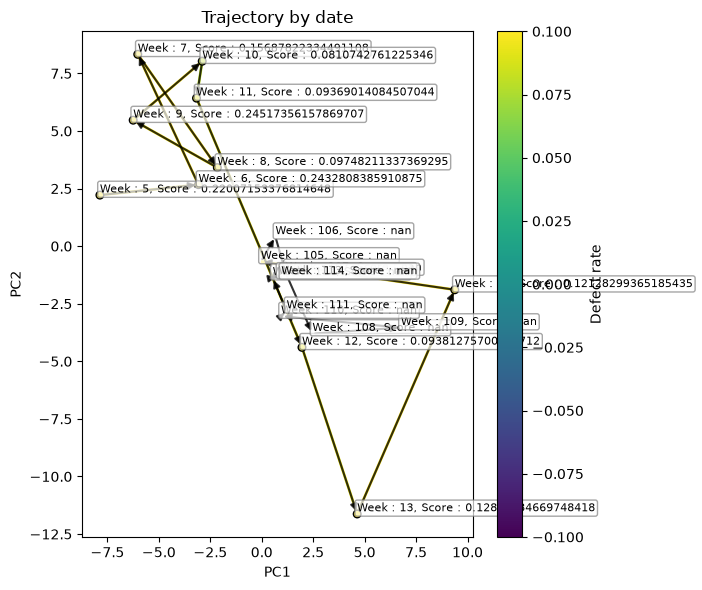

In [65]:


points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(score.min(), score.max())

lc = LineCollection(
    segments,
    cmap='viridis',
    norm=norm,
    linewidth=2
)
lc.set_array(score[:-1])

fig, ax = plt.subplots(figsize=(7,6))
ax.add_collection(lc)

# Scatter
sc = ax.scatter(
    x, y,
    c=score,
    cmap='viridis',
    norm=norm,
    s=30,
    edgecolor='k',
    zorder=3
)

# #1. 화살표 추가
for i in range(len(x) - 1) : 
    arrow = FancyArrowPatch(
        (x[i], y[i]),
        (x[i+1], y[i+1]),
        arrowstyle="-|>",
        mutation_scale=10,
        color=plt.cm.viridis(norm(score[i])),
        linewidth=1.5,
        alpha=0.8,
        zorder=2,
    )
    ax.add_patch(arrow)

# 2. 레이블 추가
for real_idx, idx in enumerate(data_sv_pca.index.tolist()) : 
    ax.text(
        x[real_idx],
        y[real_idx],
        f"Week : {week[real_idx]}, Score : {score[real_idx]}",
        fontsize=8,
        ha='left',
        va='bottom',
        bbox=dict(
            boxstyle="round,pad=0.2",
            fc='white',
            alpha=0.7,
            ec='gray'
        )
    )

ax.autoscale()

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Defect rate')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectory by date")

plt.tight_layout()
plt.show()